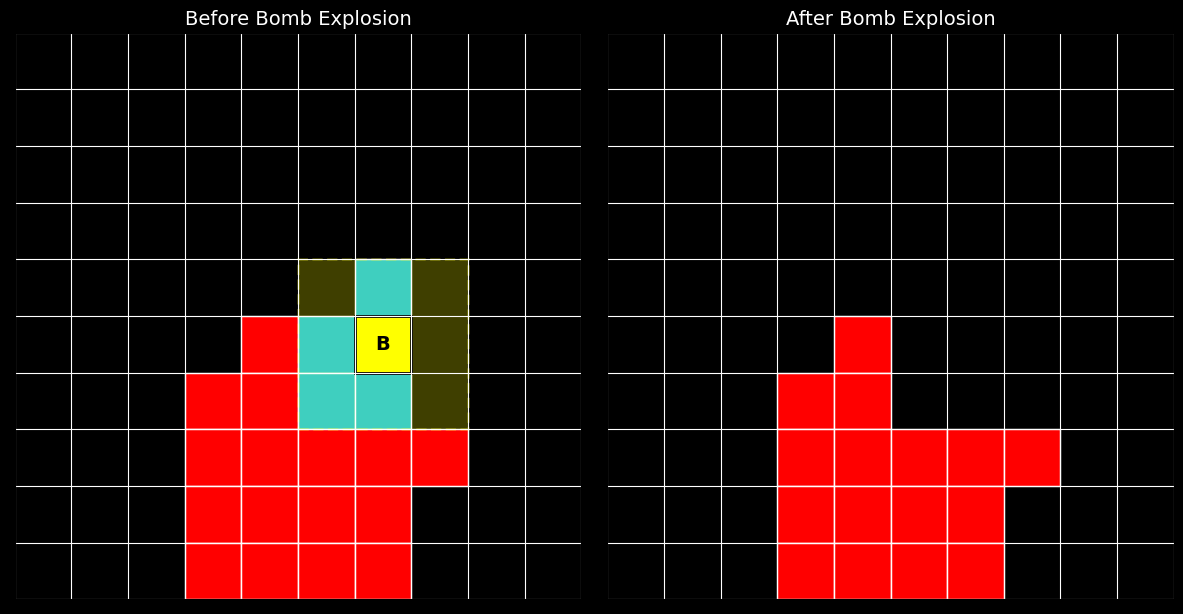

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle

def draw_board(ax, grid, title,
               bomb_pos=None,
               radius=1,
               cleared_cells=None):

    rows, cols = grid.shape

    ax.set_facecolor("black")

    for y in range(rows):
        for x in range(cols):

            if grid[y, x] == 1:
                color = "red"

                if cleared_cells and (y, x) in cleared_cells:
                    color = "deepskyblue"

                rect = Rectangle(
                    (x, rows - y - 1),
                    1,
                    1,
                    facecolor=color,
                    edgecolor="white",
                    linewidth=1
                )
                ax.add_patch(rect)

    if bomb_pos is not None:
        bomb_y, bomb_x = bomb_pos

        radius_box = Rectangle(
            (bomb_x - radius,
             rows - bomb_y - radius - 1),
            2 * radius + 1,
            2 * radius + 1,
            facecolor="yellow",
            alpha=0.25,
            edgecolor="yellow",
            linewidth=2,
            linestyle="--"
        )

        ax.add_patch(radius_box)

        bomb_square = Rectangle(
            (bomb_x, rows - bomb_y - 1),
            1,
            1,
            facecolor="yellow",
            edgecolor="black",
            linewidth=2
        )

        ax.add_patch(bomb_square)

        ax.text(
            bomb_x + 0.5,
            rows - bomb_y - 0.5,
            "B",
            ha="center",
            va="center",
            fontsize=14,
            fontweight="bold",
            color="black"
        )

    ax.set_xticks(np.arange(0, cols + 1, 1))
    ax.set_yticks(np.arange(0, rows + 1, 1))
    ax.grid(color="white", linewidth=0.8)

    ax.set_xlim(0, cols)
    ax.set_ylim(0, rows)

    ax.set_xticklabels([])
    ax.set_yticklabels([])

    ax.set_title(title, color="white", fontsize=14)

    ax.set_aspect("equal")


def create_bomb_visualization():

    before = np.zeros((10, 10))

    before[6:10, 3:7] = 1
    before[5, 4] = 1
    before[5, 5] = 1
    before[4, 6] = 1
    before[7, 7] = 1

    bomb_y, bomb_x = 5, 6
    radius = 1

    before[bomb_y, bomb_x] = 2

    after = before.copy()

    cleared_cells = []

    for y in range(bomb_y - radius,
                   bomb_y + radius + 1):
        for x in range(bomb_x - radius,
                       bomb_x + radius + 1):

            if 0 <= y < 10 and 0 <= x < 10:

                if after[y, x] == 1:
                    cleared_cells.append((y, x))

                after[y, x] = 0

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(12, 6),
        facecolor="black"
    )

    draw_board(
        axes[0],
        before,
        "Before Bomb Explosion",
        bomb_pos=(bomb_y, bomb_x),
        radius=radius,
        cleared_cells=cleared_cells
    )

    draw_board(
        axes[1],
        after,
        "After Bomb Explosion"
    )

    plt.tight_layout()

    plt.savefig(
        "bomb_piece_visualization.png",
        dpi=300,
        facecolor="black",
        bbox_inches="tight"
    )

    plt.show()


create_bomb_visualization()

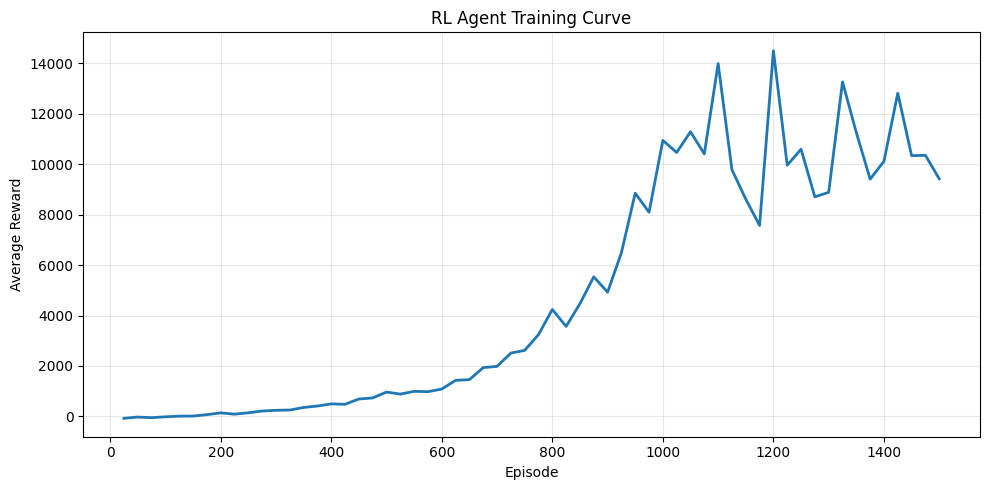

In [4]:
import matplotlib.pyplot as plt

episodes = list(range(25, 1501, 25))

avg_game_score = [
    -77.19, -26.03, -50.26, -15.96, 9.36, 13.36, 68.53,
    140.08, 88.41, 143.74, 212.78, 241.80, 251.82,
    354.28, 410.70, 494.88, 480.15, 689.18, 732.11,
    964.82, 884.51, 992.65, 980.34, 1083.52, 1429.01,
    1458.20, 1933.83, 1983.27, 2511.07, 2617.34,
    3242.44, 4238.25, 3567.93, 4470.03, 5533.83,
    4925.31, 6488.16, 8850.15, 8096.31, 10942.52,
    10464.74, 11287.76, 10406.93, 13988.60, 9781.26,
    8613.31, 7572.00, 14499.07, 9959.42, 10594.36,
    8704.59, 8884.04, 13265.24, 11254.83, 9407.32,
    10115.63, 12814.81, 10337.66, 10352.81, 9420.14
]

plt.figure(figsize=(10, 5))
plt.plot(episodes, avg_game_score, linewidth=2)

plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.title("RL Agent Training Curve")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("rl_training_curve.png", dpi=300)
plt.show()



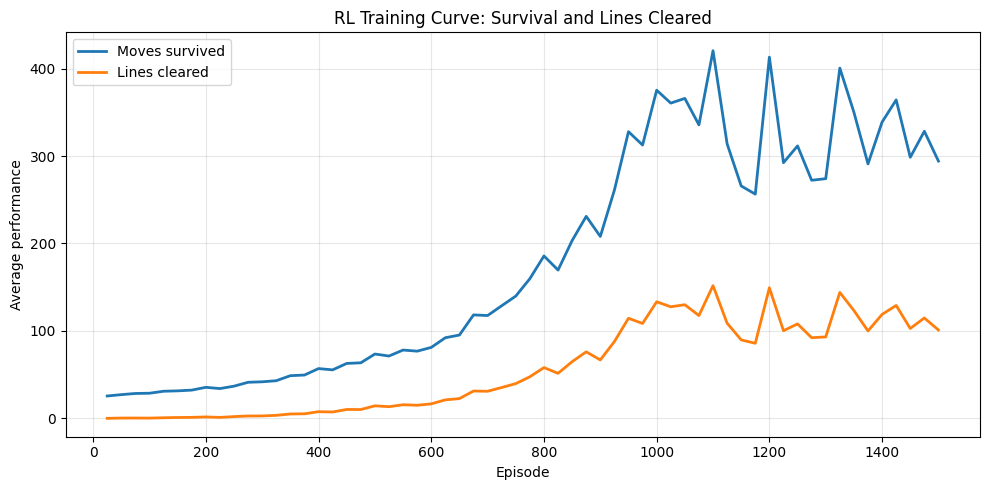

In [5]:
import matplotlib.pyplot as plt

episodes = list(range(25, 1501, 25))

moves = [
    25.56, 27.12, 28.44, 28.72, 31.00, 31.44, 32.28, 35.48,
    34.04, 36.80, 41.24, 41.80, 43.04, 48.80, 49.52, 56.92,
    55.44, 62.80, 63.52, 73.56, 71.28, 78.12, 76.84, 81.12,
    92.20, 95.28, 118.28, 117.60, 128.76, 139.84, 159.76,
    185.76, 169.60, 203.36, 231.04, 208.04, 261.04, 327.84,
    312.60, 375.32, 360.56, 365.92, 335.68, 420.48, 314.00,
    265.80, 256.44, 413.12, 292.40, 311.60, 272.32, 274.12,
    400.60, 350.08, 291.04, 338.84, 364.24, 298.56, 328.36,
    294.24
]

lines = [
    0.00, 0.32, 0.36, 0.28, 0.68, 0.96, 1.12, 1.60,
    1.08, 2.00, 2.68, 2.76, 3.44, 5.00, 5.20, 7.60,
    7.28, 10.16, 10.08, 14.32, 13.32, 15.56, 14.96,
    16.56, 21.12, 22.60, 31.24, 30.96, 35.28, 39.72,
    47.56, 58.04, 51.48, 64.84, 76.08, 66.80, 87.84,
    114.44, 108.52, 133.32, 127.60, 129.96, 117.56,
    151.80, 108.84, 89.72, 85.84, 149.36, 100.24,
    108.00, 92.24, 93.12, 144.00, 123.32, 99.96,
    118.88, 129.12, 102.76, 114.80, 101.08
]

plt.figure(figsize=(10, 5))

plt.plot(
    episodes,
    moves,
    label="Moves survived",
    linewidth=2
)

plt.plot(
    episodes,
    lines,
    label="Lines cleared",
    linewidth=2
)

plt.xlabel("Episode")
plt.ylabel("Average performance")
plt.title("RL Training Curve: Survival and Lines Cleared")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("rl_training_moves_lines.png", dpi=300)
plt.show()